### Exploring other setting for the hyperparameter search

Here we perform the threshold search with different settings to show that the plot is consistend and there aren't massive differences in the outcome based on hyperparameter choice

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

clin = pd.read_csv('/Users/smasarone/Desktop/Atom_Trauma/Trauma_ML/XGB_grid_search/clin_ready.csv', header = 0, index_col=0)
prot = pd.read_csv('/Users/smasarone/Desktop/Trauma_data_scripts/data_final/dataset_final_4979prot.csv',
                   header = 0, index_col = 0)

clin = clin.drop(labels = 1578, axis = 0)
print("prot shape", prot.shape)
print("clin shape", clin.shape)

# scale 
X = StandardScaler().fit_transform(prot)
df_scaled = pd.DataFrame(X)
df_scaled.columns = prot.columns
df_scaled.index = prot.index

prot shape (414, 4979)
clin shape (414, 38)


best train res 1.0
eval: [0.877504, 0.897059, 0.89254, 0.885833, 0.879183, 0.881398, 0.88307, 0.859946, 0.858197, 0.900165, 0.890605, 0.871681] [49, 40, 20, 26, 21, 20, 20, 38, 30, 35, 43, 47]


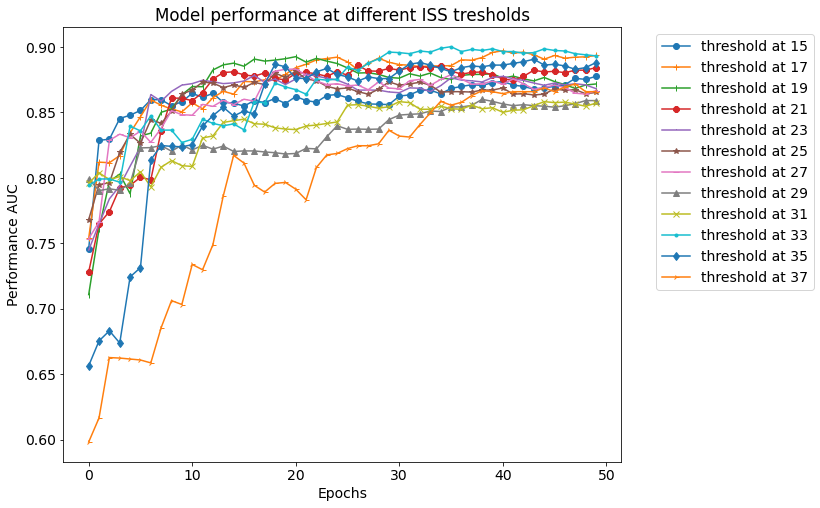

In [5]:
#define groups for model
import xgboost as xgb
import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties
import itertools


res = []
iterations= []
iterations_ = []
models = []
score = []
labels_ =[]
min_thr=15
max_thr=39
step=2

for n in range(min_thr, max_thr, step):
    labels_.append("threshold at "+ str(n))
    target = []
    for i in clin['iss']:
        if i > n:
            target.append(1)
        else:
            target.append(0)
    
    y = target
    
    #split train and test
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(df_scaled, y, test_size = 0.3, random_state = 32)        
            
    dtrain = xgb.DMatrix(X_train, label= y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    param = {'max_depth': 2, 'eta': 0.1, 'objective': 'binary:logistic'}
    param['nthread'] = -1
    param['eval_metric'] = 'auc'
    num_round = 50
    evallist = [(dtest, 'eval'), (dtrain, 'train')]
    progress = {}
    bst = xgb.train(param, dtrain, num_round, evallist, evals_result = progress, verbose_eval=0, early_stopping_rounds=35) 
    
    models.append(bst)
    
    #check if training goes to 1 
    position_ = np.argmax(progress['train']['auc'])
    iterations_.append(position_)
    best_res_ = progress['train']['auc'][position_] #check if there's a 1

    #save best result at best iteration
    position = np.argmax(progress['eval']['auc']) #position best score
    iterations.append(position)                   #save all position of best iterations
    best_res = progress['eval']['auc'][position]  #best result
    res.append(best_res)                          #save best result
    
    #append scores
    score.append(progress['eval']['auc'][:])
    
      
score_array = np.asarray(score)
score_array = score_array.T    
fontP = FontProperties()
fontP.set_size('medium')
#print(progress)

markers =["o","+","|","8", ",","*","_","^","x",".","d","4"]

ax = plt.figure(figsize=(10,8))
ax = plt.xlabel("Epochs")
ax = plt.ylabel("Performance AUC")
ax = plt.rcParams.update({'font.size': 14})  #font at 23 to save


for i,z in enumerate(markers):
    
    ax = plt.plot(score_array[:,i], marker=z) 
    
plt.legend(labels=labels_, bbox_to_anchor=(1.05, 1), prop=fontP)    
plt.title("Model performance at different ISS tresholds")
plt.savefig('threshold_iss.pdf', bbox_inches = 'tight')

print("best train res", best_res_)   
print("eval:", res, iterations)

best train res 1.0
eval: [0.86415, 0.863777, 0.866458, 0.885833, 0.880885, 0.875, 0.86166, 0.854312, 0.842657, 0.882426, 0.870656, 0.849558] [37, 24, 17, 16, 39, 17, 37, 38, 39, 39, 38, 37]


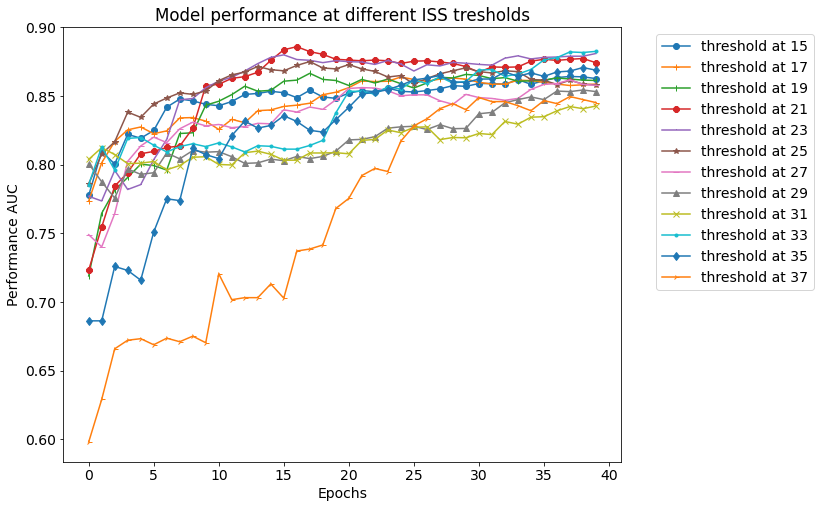

In [3]:
res = []
iterations= []
iterations_ = []
models = []
score = []
labels_ =[]
min_thr=15
max_thr=39
step=2

for n in range(min_thr, max_thr, step):
    labels_.append("threshold at "+ str(n))
    target = []
    for i in clin['iss']:
        if i > n:
            target.append(1)
        else:
            target.append(0)
    
    y = target
    
    #split train and test
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(df_scaled, y, test_size = 0.3, random_state = 32)        
            
    dtrain = xgb.DMatrix(X_train, label= y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    param = {'max_depth': 3, 'eta': 0.1, 'objective': 'binary:logistic'}
    param['nthread'] = -1
    param['eval_metric'] = 'auc'
    num_round = 40
    evallist = [(dtest, 'eval'), (dtrain, 'train')]
    progress = {}
    bst = xgb.train(param, dtrain, num_round, evallist, evals_result = progress, verbose_eval=0, early_stopping_rounds=35) 
    
    models.append(bst)
    
    #check if training goes to 1 
    position_ = np.argmax(progress['train']['auc'])
    iterations_.append(position_)
    best_res_ = progress['train']['auc'][position_] #check if there's a 1

    #save best result at best iteration
    position = np.argmax(progress['eval']['auc']) #position best score
    iterations.append(position)                   #save all position of best iterations
    best_res = progress['eval']['auc'][position]  #best result
    res.append(best_res)                          #save best result
    
    #append scores
    score.append(progress['eval']['auc'][:])
    
      
score_array = np.asarray(score)
score_array = score_array.T    
fontP = FontProperties()
fontP.set_size('medium')
#print(progress)

markers =["o","+","|","8", ",","*","_","^","x",".","d","4"]

ax = plt.figure(figsize=(10,8))
ax = plt.xlabel("Epochs")
ax = plt.ylabel("Performance AUC")
ax = plt.rcParams.update({'font.size': 14})  #font at 23 to save


for i,z in enumerate(markers):
    
    ax = plt.plot(score_array[:,i], marker=z) 
    
plt.legend(labels=labels_, bbox_to_anchor=(1.05, 1), prop=fontP)    
plt.title("Model performance at different ISS tresholds")
plt.savefig('threshold_iss.pdf', bbox_inches = 'tight')

print("best train res", best_res_)   
print("eval:", res, iterations)

best train res 1.0
eval: [0.894026, 0.882922, 0.885281, 0.905923, 0.912045, 0.854921, 0.826356, 0.890335, 0.892857, 0.891026, 0.90708, 0.873478] [21, 35, 38, 46, 37, 8, 69, 21, 33, 42, 18, 17]


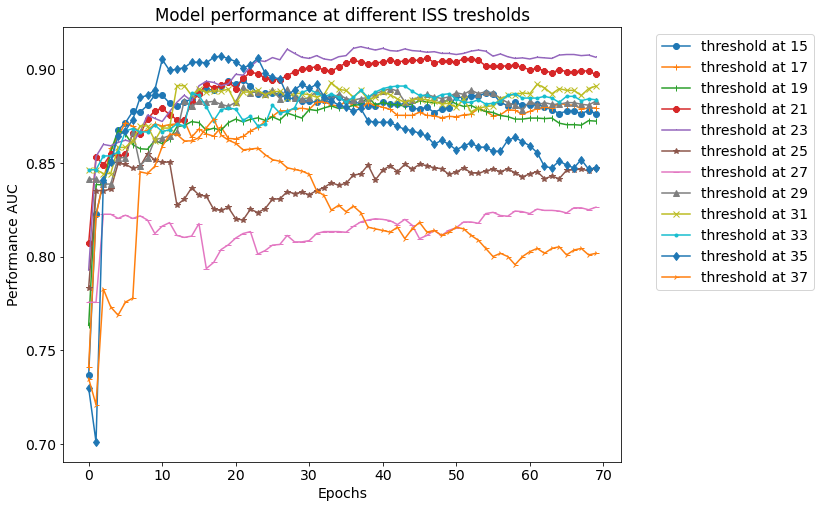

In [4]:
res = []
iterations= []
iterations_ = []
models = []
score = []
labels_ =[]
min_thr=15
max_thr=39
step=2

for n in range(min_thr, max_thr, step):
    labels_.append("threshold at "+ str(n))
    target = []
    for i in clin['iss']:
        if i > n:
            target.append(1)
        else:
            target.append(0)
    
    y = target
    
    #split train and test
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(df_scaled, y, test_size = 0.3, random_state = 40)        
            
    dtrain = xgb.DMatrix(X_train, label= y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    param = {'max_depth': 1, 'eta': 0.2, 'objective': 'binary:logistic'}
    param['nthread'] = -1
    param['eval_metric'] = 'auc'
    num_round = 70
    evallist = [(dtest, 'eval'), (dtrain, 'train')]
    progress = {}
    bst = xgb.train(param, dtrain, num_round, evallist, evals_result = progress, verbose_eval=0, early_stopping_rounds=35) 
    
    models.append(bst)
    
    #check if training goes to 1 
    position_ = np.argmax(progress['train']['auc'])
    iterations_.append(position_)
    best_res_ = progress['train']['auc'][position_] #check if there's a 1

    #save best result at best iteration
    position = np.argmax(progress['eval']['auc']) #position best score
    iterations.append(position)                   #save all position of best iterations
    best_res = progress['eval']['auc'][position]  #best result
    res.append(best_res)                          #save best result
    
    #append scores
    score.append(progress['eval']['auc'][:])
    
      
score_array = np.asarray(score)
score_array = score_array.T    
fontP = FontProperties()
fontP.set_size('medium')
#print(progress)

markers =["o","+","|","8", ",","*","_","^","x",".","d","4"]

ax = plt.figure(figsize=(10,8))
ax = plt.xlabel("Epochs")
ax = plt.ylabel("Performance AUC")
ax = plt.rcParams.update({'font.size': 14})  #font at 23 to save


for i,z in enumerate(markers):
    
    ax = plt.plot(score_array[:,i], marker=z) 
    
plt.legend(labels=labels_, bbox_to_anchor=(1.05, 1), prop=fontP)    
plt.title("Model performance at different ISS tresholds")
plt.savefig('threshold_iss.pdf', bbox_inches = 'tight')

print("best train res", best_res_)   
print("eval:", res, iterations)